# CS680: Assignment 1

## Exercise 1.1

Run your perceptron algorithm on the spambase dataset and plot the number of mistakes (y-axis) wrt the number of passes (x-axis).

---

Let's start by loading the dataset spambase_y.csv that contains the labels for the spambase dataset.

In [48]:
import os
from CS680.assignments.a1.utils.ReadData import ReadY, ReadX
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

y = ReadY("./datasets/spambase_y.csv")


>>> Reading data from: ./datasets/spambase_y.csv ...
#instances: 4601
>>> Reading finished! Data are converted to numpy array.
shape of y: (4601,)


Now, let's manipulate the spambase_X.csv, so we can have feature vectors for each training example.

In [49]:
spambase_x_df = pd.read_csv("./datasets/spambase_X.csv", header=None)

spambase_x_df = spambase_x_df.T
X = spambase_x_df.to_numpy()

print(X.shape == (4601, 57))
print(y.shape == (4601,))

True
True


Function to train the perceptron that will also compute the number of mistakes for each pass.

In [50]:
def train_perceptron(X, y, epochs=500):
    mistakes_vector = list()

    d = X.shape[1]

    w = np.zeros(d)
    b = 0.0

    for epoch in range(epochs):
        mistakes = 0

        for x_i, y_i in zip(X, y):

            score = np.dot(x_i, w) + b

            if y_i * score <= 0:
                w += y_i * x_i

                b += y_i

                mistakes += 1

        if mistakes == 0:
            break

        mistakes_vector.append(mistakes)

    return w, b, mistakes_vector

Let's train the perceptron and graph the number of mistakes for each pass.

Weights: [  -3049.96         -2072.76          2570.84          8528.
   15662.78         10178.76         25650.04         16466.55
    2706.06          5957.26          2062.9          -9466.11
    2160.83          5810.46         11921.21         22527.90999999
   14898.31          4777.8           7002.25         19680.82
    5398.8           5271.86         31882.56         16726.35
 -103520.52000001  -42337.21        -34303.34000001   -5694.76
  -13719.14        -13815.84        -10473.75         -6506.22
  -30877.53         -5978.19        -17529.89         -4638.43
  -27700.04         -3758.04        -12601.5          -6953.21
  -10678.61        -22156.63         -7015.36        -11290.2
  -20352.75000001  -39992.52999999   -3354.78        -10483.95
  -21847.439       -11896.114        -4048.328        19262.03799999
   23455.049         3450.032        -1337.126         1605.
     280.        ]
Bias: -63656.00


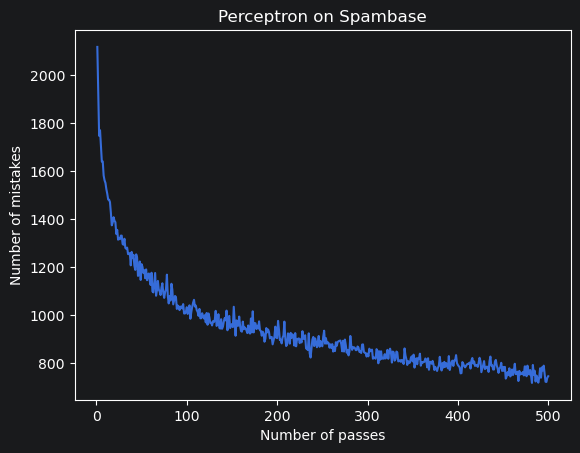

In [51]:
w, b, mistakes = train_perceptron(X, y)

plt.plot(range(1, len(mistakes) + 1), mistakes)

print(f"Weights: {w}")
print(f"Bias: {b:.2f}")
plt.xlabel("Number of passes")
plt.ylabel("Number of mistakes")
plt.title("Perceptron on Spambase")

plt.show()

---

## Exercise 1.2

Prove that in each iteration, the (binary) perceptron algorithm essentially picks a term from the above summation, computes the corresponding derivative (say g), and performs a gradient update.

Perceptron loss function for one training example

$$
\ell_i(w) = \max(0, -y_i x_i^T w)
$$

The idea of this interpretation is that we're using the gradient to update the weights. This way we'll be minimizing the weights. The algorithm behavior essentially does not change with the gradient update. This is just the proof of the perceptron algorithm.

There are two cases.

### Case 1: Correctly classified

If

$$
y_i x_i^T w > 0
$$

then

$$
-y_i x_i^T w < 0
$$

so

$$
\ell_i(w) = 0
$$

Therefore, the gradient is

$$
g = \nabla \ell_i(w) = 0
$$

and the update is

$$
w \leftarrow w - g = w
$$

so the weights do not change.

### Case 2: Misclassified

If

$$
y_i x_i^T w < 0
$$

then

$$
\ell_i(w) = -y_i x_i^T w
$$

The gradient with respect to $w$ is

$$
g = \nabla \ell_i(w) = -y_i x_i
$$

The gradient update is

$$
w \leftarrow w - g
$$

Substituting the gradient,

$$
w \leftarrow w - (-y_i x_i)
$$

therefore,

$$
\boxed{w \leftarrow w + y_i x_i}
$$

This is exactly the standard perceptron update rule.

Therefore, in each iteration, the perceptron selects one term from

$$
\sum_{i=1}^{n} \max(0, -y_i x_i^T w)
$$

computes its gradient, and performs a gradient update.

---

## Exercise 1.3

The multiclass perceptron objective is

$$
\min_{w_1,\ldots,w_c}
\sum_{i=1}^{n}
\max_{k=1,\ldots,c}
\left[
\langle x_i,w_k\rangle
-
\langle x_i,w_{y_i}\rangle
\right]
$$

When $c=2$, there are only two weight vectors $w_1$ and $w_2$

Define a single weight vector

$$
w = w_1-w_2.
$$

We consider the two possible classes.

### Case 1: $y_i=1$

The loss for example $i$ is

$$
\max
\left\{
\langle x_i,w_1\rangle-\langle x_i,w_1\rangle,
\;
\langle x_i,w_2\rangle-\langle x_i,w_1\rangle
\right\}.
$$

Therefore,

$$
=
\max
\left\{
0,
\langle x_i,w_2-w_1\rangle
\right\}.
$$

Since $w=w_1-w_2$,

$$
=
\max\{0,-\langle x_i,w\rangle\}.
$$

If we represent class 1 by the binary label $y_i=+1$, this becomes

$$
\max\{0,-y_i\langle x_i,w\rangle\}.
$$

### Case 2: $y_i=2$

The loss is

$$
\max
\left\{
\langle x_i,w_1\rangle-\langle x_i,w_2\rangle,
\;
\langle x_i,w_2\rangle-\langle x_i,w_2\rangle
\right\}.
$$

Therefore,

$$
=
\max\{0,\langle x_i,w_1-w_2\rangle\}.
$$

Using $w=w_1-w_2$,

$$
=
\max\{0,\langle x_i,w\rangle\}.
$$

If we represent class 2 by the binary label $y_i=-1$, then

$$
\max\{0,\langle x_i,w\rangle\}
=
\max\{0,-y_i\langle x_i,w\rangle\}.
$$

Therefore, for both classes, the objective becomes

$$
\boxed{
\min_w
\sum_{i=1}^{n}
\max\{0,-y_i\langle x_i,w\rangle\}
}
$$

where $y_i\in\{+1,-1\}$.

This is exactly the binary perceptron objective. Therefore, when $c=2$,
the multiclass perceptron reduces to the binary perceptron.

---

## Exercise 1.4

Develop and implement a multiclass perceptron algorithm. Run your implementation on the activity dataset and report the final errors on the training and test sets.

We want to develop a multiclass version of the perceptron.

In the binary perceptron, we use one weight vector to decide between two
classes. In the multiclass case, we use one weight vector $w_k$ for each
class $k$.

For every training example $(x_i, y_i)$, we calculate one score for every
class:

$$
\text{score}_k = \langle x_i, w_k \rangle.
$$

Then, we predict the class with the largest score:

$$
\hat{y}_i =
\arg\max_{k=1,\ldots,c}
\langle x_i, w_k \rangle.
$$

If the predicted class is correct, we do not update the weights.

If the predicted class is incorrect, we want to increase the score of the
correct class and decrease the score of the incorrectly predicted class.

Therefore, we update:

$$
w_{y_i} \leftarrow w_{y_i} + x_i,
$$

and

$$
w_{\hat{y}_i} \leftarrow w_{\hat{y}_i} - x_i.
$$

The weight vectors of the other classes are not changed.

### Pseudocode

1. Initialize one weight vector for each class with zeros.
2. Repeat for a fixed number of passes:
   - For every training example $(x_i, y_i)$:
     - Compute the score of every class.
     - Predict the class with the largest score.
     - If the prediction is wrong:
       - Add $x_i$ to the weight vector of the correct class.
       - Subtract $x_i$ from the weight vector of the predicted class.
3. Return the learned weight vectors.

In [52]:
X_train = np.loadtxt("./datasets/activity_X_train.txt")
X_test = np.loadtxt("./datasets/activity_X_test.txt")

y_train = np.loadtxt("./datasets/activity_y_train.txt", dtype=int)
y_test = np.loadtxt("./datasets/activity_y_test.txt", dtype=int)


In [53]:
def predict_multiclass(X, W, classes):
    predictions = []

    for x_i in X:
        scores = W @ x_i
        predicted_index = np.argmax(scores)
        predictions.append(classes[predicted_index])

    return np.array(predictions)

In [54]:
def classification_error(y_true, y_pred):
    return np.mean(y_true != y_pred)

In [55]:
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

print(f"Classes: {np.unique(y_train)}")

X_train: (7352, 561)
y_train: (7352,)
X_test: (2947, 561)
y_test: (2947,)
Classes: [1 2 3 4 5 6]


In [56]:
def train_multiclass_perceptron(X, y, num_passes=20):
    n_samples, n_features = X.shape

    classes = np.unique(y)
    n_classes = len(classes)

    W = np.zeros((n_classes, n_features))

    mistakes_per_pass = []

    for epoch in range(num_passes):
        mistakes = 0

        for x_i, y_i in zip(X, y):

            # Compute score for each class
            scores = W @ x_i

            # argmax gives an index: 0, 1, ..., 5
            predicted_index = np.argmax(scores)

            # Labels are 1, 2, ..., 6
            true_index = y_i - 1

            if predicted_index != true_index:
                # Increase score of correct class
                W[true_index] += x_i

                # Decrease score of incorrectly predicted class
                W[predicted_index] -= x_i

                mistakes += 1

        mistakes_per_pass.append(mistakes)

        print(
            f"Pass {epoch + 1}: "
            f"{mistakes} mistakes"
        )

    return W, mistakes_per_pass

In [57]:
def predict_multiclass(X, W):
    predictions = []

    for x_i in X:
        scores = W @ x_i

        predicted_index = np.argmax(scores)

        # Convert index 0..5 back into label 1..6
        predicted_label = predicted_index + 1

        predictions.append(predicted_label)

    return np.array(predictions)

In [58]:
def classification_error(y_true, y_pred) -> float:
    return float(np.mean(y_true != y_pred))

In [59]:
W, mistakes = train_multiclass_perceptron(
    X_train,
    y_train,
    num_passes=500
)

Pass 1: 290 mistakes
Pass 2: 246 mistakes
Pass 3: 202 mistakes
Pass 4: 198 mistakes
Pass 5: 173 mistakes
Pass 6: 167 mistakes
Pass 7: 165 mistakes
Pass 8: 153 mistakes
Pass 9: 140 mistakes
Pass 10: 140 mistakes
Pass 11: 132 mistakes
Pass 12: 127 mistakes
Pass 13: 132 mistakes
Pass 14: 127 mistakes
Pass 15: 122 mistakes
Pass 16: 104 mistakes
Pass 17: 110 mistakes
Pass 18: 102 mistakes
Pass 19: 105 mistakes
Pass 20: 100 mistakes
Pass 21: 105 mistakes
Pass 22: 109 mistakes
Pass 23: 101 mistakes
Pass 24: 100 mistakes
Pass 25: 102 mistakes
Pass 26: 92 mistakes
Pass 27: 80 mistakes
Pass 28: 96 mistakes
Pass 29: 88 mistakes
Pass 30: 96 mistakes
Pass 31: 92 mistakes
Pass 32: 94 mistakes
Pass 33: 95 mistakes
Pass 34: 97 mistakes
Pass 35: 88 mistakes
Pass 36: 95 mistakes
Pass 37: 97 mistakes
Pass 38: 89 mistakes
Pass 39: 84 mistakes
Pass 40: 89 mistakes
Pass 41: 73 mistakes
Pass 42: 76 mistakes
Pass 43: 85 mistakes
Pass 44: 82 mistakes
Pass 45: 74 mistakes
Pass 46: 86 mistakes
Pass 47: 68 mistak

In [60]:
y_train_pred = predict_multiclass(X_train, W)
y_test_pred = predict_multiclass(X_test, W)

train_error = classification_error(
    y_train,
    y_train_pred
)

test_error = classification_error(
    y_test,
    y_test_pred
)

print(f"Training error: {train_error:.4f}")
print(f"Test error: {test_error:.4f}")

print(f"Training error: {train_error * 100:.2f}%")
print(f"Test error: {test_error * 100:.2f}%")

Training error: 0.0174
Test error: 0.0478
Training error: 1.74%
Test error: 4.78%


---

## Exercise 2.1

Show the (binary) square loss is proper.

We want to prove that the expected square loss is minimized when our predicted probability $p$ is equal to the true probability $q$.

We are given

$$
q = \Pr(Y=1).
$$

Since $Y$ is binary,

$$
\Pr(Y=0)=1-q.
$$

Therefore, $Y$ can only take the values

$$
Y=1
$$

or

$$
Y=0.
$$

We want to solve

$$
\min_p \mathbb E(Y-p)^2.
$$

First, we write the expected loss by considering both possible outcomes of $Y$:

$$
L(p)
=
\mathbb E(Y-p)^2
=
\Pr(Y=1)(1-p)^2
+
\Pr(Y=0)(0-p)^2.
$$

Substituting the probabilities,

$$
L(p)
=
q(1-p)^2
+
(1-q)(0-p)^2.
$$

Since $(0-p)^2=p^2$,

$$
L(p)
=
q(1-p)^2+(1-q)p^2.
$$

Expanding,

$$
L(p)
=
q(1-2p+p^2)+(1-q)p^2,
$$

$$
L(p)
=
q-2qp+qp^2+p^2-qp^2.
$$

Therefore,

$$
L(p)=q-2qp+p^2.
$$

To find the value of $p$ that minimizes the expected loss, we differentiate with respect to $p$:

$$
\frac{dL}{dp}=2p-2q.
$$

Setting the derivative equal to zero,

$$
2p-2q=0,
$$

which gives

$$
p=q.
$$

Finally,

$$
\frac{d^2L}{dp^2}=2>0,
$$

so $L(p)$ is strictly convex and $p=q$ is the unique minimum.

Therefore, the expected square loss is uniquely minimized when the predicted probability $p$ equals the true probability $q$.

Hence, the binary square loss is strictly proper.

---

## Exercise 2.2

Extend the square loss to the multi-class setting and show if it remains (strictly) proper.

Now we consider the multi-class setting.

We are given

$$
\Pr(Y=e_k)=p_k,
\qquad k=1,\ldots,c,
$$

where $e_k$ is the $k$-th standard basis vector. This means that $e_k$ has a $1$ in position $k$ and $0$ everywhere else.

For example, if $c=3$,

$$
e_1=
\begin{bmatrix}
1\\
0\\
0
\end{bmatrix},
\qquad
e_2=
\begin{bmatrix}
0\\
1\\
0
\end{bmatrix},
\qquad
e_3=
\begin{bmatrix}
0\\
0\\
1
\end{bmatrix}.
$$

The true probability vector is

$$
p=(p_1,\ldots,p_c),
$$

with

$$
p_k\ge 0
$$

and

$$
\sum_{k=1}^c p_k=1.
$$

Let

$$
r=(r_1,\ldots,r_c)
$$

be our predicted probability vector, where $r\in\Delta$.

We extend the binary square loss to the multi-class case by using the squared Euclidean distance between the observed one-hot vector and our predicted probability vector:

$$
s(e_k,r)=\|e_k-r\|^2.
$$

The expected square loss is therefore

$$
L(r)
=
\sum_{k=1}^c
p_k\|e_k-r\|^2.
$$

Now we expand the squared norm:

$$
\|e_k-r\|^2
=
\|e_k\|^2
-
2e_k^Tr
+
\|r\|^2.
$$

Since $e_k$ is a standard basis vector,

$$
\|e_k\|^2=1,
$$

and

$$
e_k^Tr=r_k.
$$

Therefore,

$$
L(r)
=
\sum_{k=1}^c
p_k
\left(
1-2r_k+\|r\|^2
\right).
$$

Since

$$
\sum_{k=1}^c p_k=1,
$$

we get

$$
L(r)
=
1
-
2\sum_{k=1}^c p_kr_k
+
\|r\|^2.
$$

Using vector notation,

$$
L(r)
=
1-2p^Tr+\|r\|^2.
$$

Now we add and subtract $\|p\|^2$:

$$
L(r)
=
\|r\|^2
-
2p^Tr
+
\|p\|^2
+
1-\|p\|^2.
$$

The first three terms are

$$
\|r-p\|^2.
$$

Therefore,

$$
L(r)
=
\|r-p\|^2
+
1-\|p\|^2.
$$

The term

$$
1-\|p\|^2
$$

does not depend on our prediction $r$.

The only part that depends on $r$ is

$$
\|r-p\|^2.
$$

This quantity is always non-negative, and it is equal to zero only when

$$
r=p.
$$

Therefore, the expected square loss is uniquely minimized when the predicted probability vector is equal to the true probability vector.

Hence, the multi-class square loss remains strictly proper.

## Exercise 2.3

Argue that P is calibrated iff it cannot be post-improved; is a calibrated classifier necessarily accurate? Why?

We want to show that $P$ is calibrated if and only if it cannot be post-improved.

Recall that $P$ is calibrated when

$$
\Pr(Y=1 \mid P=p)=p.
$$

This means that among the examples where the model predicts probability $p$, the actual proportion of positive examples is also $p$.

For a fixed prediction $P=p$, define

$$
q_p = \Pr(Y=1 \mid P=p).
$$

Now consider the loss after applying a transformation $f$ to the prediction:

$$
\mathbb{E}[s(Y,f(p)) \mid P=p].
$$

From Exercise 2.1, we know that for square loss, the expected loss is minimized when the predicted probability is equal to the true probability.

Therefore, for the group of examples where $P=p$, the best transformed prediction is

$$
f(p)=q_p.
$$

Since

$$
q_p=\Pr(Y=1 \mid P=p),
$$

the optimal transformation is

$$
f(p)=\Pr(Y=1 \mid P=p).
$$

### If $P$ is calibrated

If $P$ is calibrated, then

$$
\Pr(Y=1 \mid P=p)=p.
$$

Therefore,

$$
f(p)=p.
$$

So the best transformation does not change the prediction. In other words,

$$
f(P)=P.
$$

Therefore, a calibrated predictor cannot be post-improved.

### If $P$ is not calibrated

If $P$ is not calibrated, then for some prediction $p$,

$$
\Pr(Y=1 \mid P=p)\neq p.
$$

In this case, we can replace $p$ by the actual probability

$$
f(p)=\Pr(Y=1 \mid P=p).
$$

From Exercise 2.1, this gives a smaller expected square loss because the square loss is strictly proper.

Therefore, if $P$ is not calibrated, it can be post-improved.

Hence,

$$
P \text{ is calibrated}
\iff
P \text{ cannot be post-improved}.
$$

### Is a calibrated classifier necessarily accurate?

No. A classifier can be calibrated without being very accurate.

Consider the predictor

$$
P=\Pr(Y=1)=q.
$$

This predictor gives the same probability $q$ for every example.

It is calibrated because

$$
\Pr(Y=1 \mid P=q)=q.
$$

However, it does not distinguish between individual examples.

For example, if $q=0.6$, the predictor always outputs $0.6$. Using a threshold of $0.5$, it would classify every example as class $1$, giving an accuracy of $60\%$.

Now consider the ideal predictor

$$
P=Y.
$$

It predicts $1$ when $Y=1$ and $0$ when $Y=0$, so it is perfectly accurate.

It is also calibrated because

$$
\Pr(Y=1 \mid P=1)=1
$$

and

$$
\Pr(Y=1 \mid P=0)=0.
$$

Therefore, both predictors are calibrated, but they can have very different accuracy.

So calibration does not necessarily imply high accuracy.